In [144]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, colors

import warnings
warnings.simplefilter('ignore')

In [145]:

n = 10
residual_coef = 0.7 # 0.8 for cold-rolled steel, 0.6 for hot-rolled steel
bmax = 1.8
br = bmax * residual_coef 
bsat = 2.03

def f(b_regular, b_residual):
    r = (bsat-b_residual-b_regular)/b_regular
    r = np.clip(r, -1, 1)
    return 0.9*np.arccos(r)


b_regular = np.linspace(0, bmax, 10*n)
b_residual = np.linspace(0, br, 10*n)

X, Y = np.meshgrid(b_regular, b_residual)
Z = f(X, Y)
print(Z.max(), Z.min())
#print(f(X, Y)[-1:])
#print(f(X, Y)[:1])


1.9620083968077962 0.0


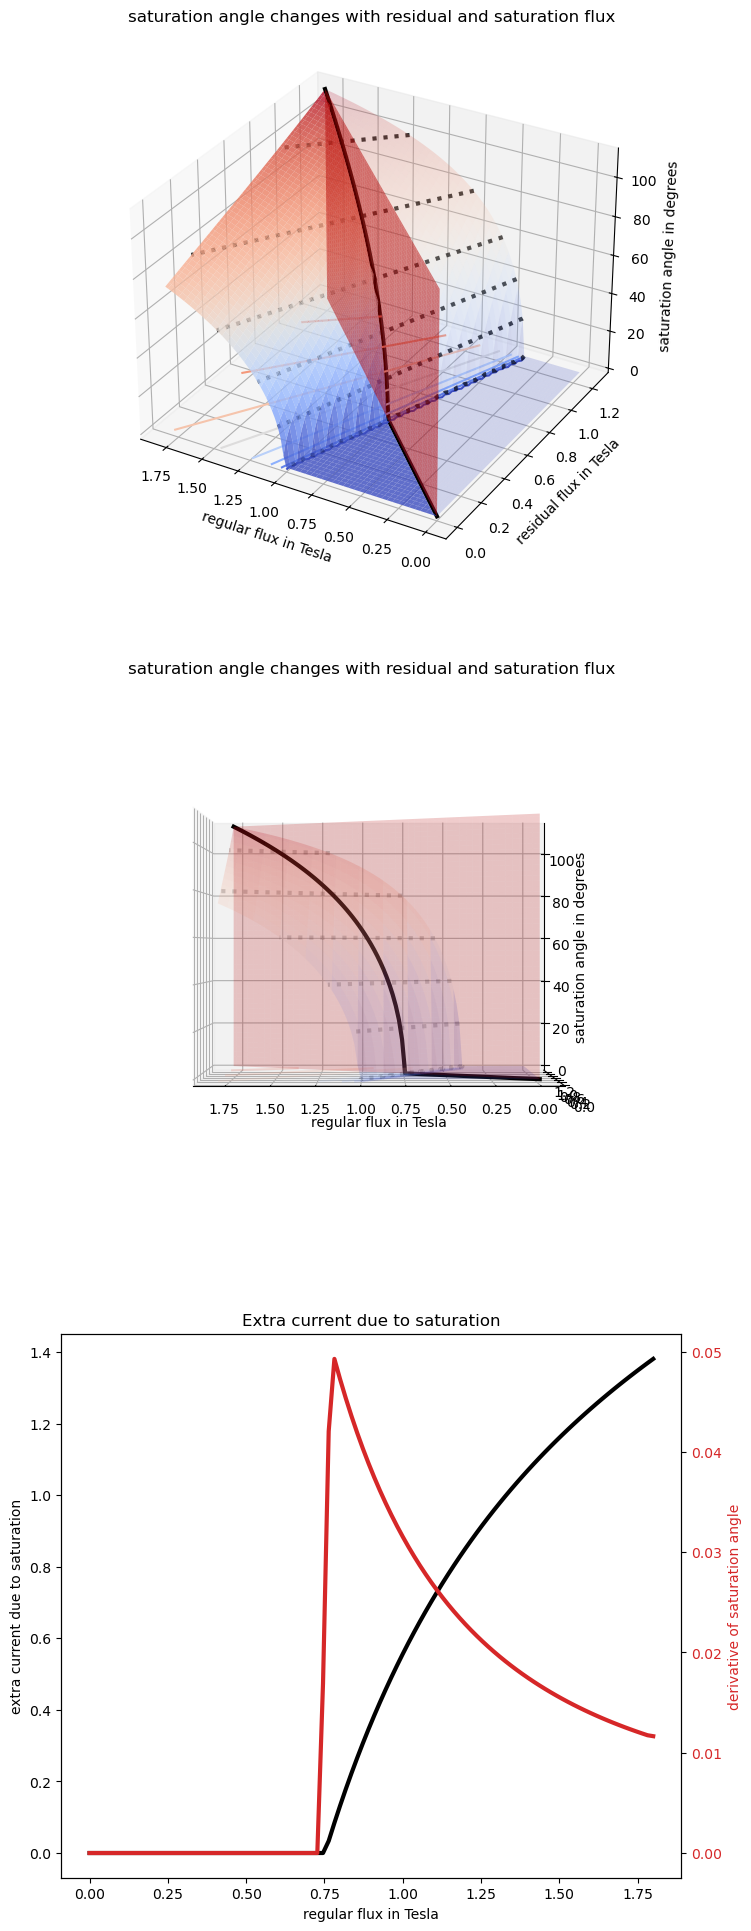

In [146]:
# creating masks for the two regions
mask_A = Y <= X * residual_coef
mask_B = ~mask_A
Z_A = np.where(mask_A, Z, np.nan)
Z_B = np.where(mask_B, Z, np.nan)


# plotting x = y*residual_coef plane
X1 = np.linspace(0, bmax, 10*n)
Z1 = np.linspace(0, f(b_residual=br,b_regular=bmax), 10*n)
X1, Z1 = np.meshgrid(X1, Z1)
Y1 = X1*residual_coef  # assuming x = x = y*residual_coef plane

# plotting intersection of x=y*residual_coef plane and the surface
X2 = np.linspace(0, bmax, 10*n)
Y2 = X2*residual_coef  # x = y*residual_coef plane
Z2 = f(b_regular=X2, b_residual=Y2)

# plotting contour levels
angle_levels = np.linspace(0, 180,10)
#print(angle_levels)


fig = plt.figure(figsize=(8,24))

ax1 = fig.add_subplot(3, 1, 1, projection='3d')
ax1.plot(X2, Y2, Z2*180/np.pi, color='black', linewidth=3)
ax1.contour(X, Y, Z*180/np.pi, zdir='z', offset=-1, cmap='coolwarm')
ax1.contour(X, Y, Z*180/np.pi, alpha=0.8, linewidths=3, colors='black', linestyles='dotted', levels=angle_levels)
#ax1.plot_surface(X, Y, Z*180/np.pi, cmap='coolwarm', edgecolor='black', rstride=8, cstride=8, alpha=0.5)
ax1.plot_surface(X, Y, Z_A*180/np.pi, cmap='coolwarm', edgecolor='none', alpha=0.8)
ax1.plot_surface(X, Y, Z_B*180/np.pi, cmap='coolwarm', edgecolor='none', alpha=0.2)  
ax1.plot_surface(X1, Y1, Z1*180/np.pi, color='red', alpha=0.5) 

ax1.set_xlabel("regular flux in Tesla")
ax1.set_ylabel("residual flux in Tesla")
ax1.set_zlabel("saturation angle in degrees")
ax1.invert_xaxis()
ax1.set_title("saturation angle changes with residual and saturation flux")

ax2 = fig.add_subplot(312, projection='3d')
ax2.plot(X2, Y2, Z2*180/np.pi, color='black', linewidth=3)
ax2.contour(X, Y, Z*180/np.pi, zdir='z', offset=-1, cmap='coolwarm', alpha=0.2)
ax2.contour(X, Y, Z*180/np.pi, alpha=0.2, linewidths=3, colors='black', linestyles='dotted', levels=angle_levels)
ax2.plot_surface(X, Y, Z*180/np.pi, cmap='coolwarm', edgecolor='none', rstride=8, cstride=8, alpha=0.2)
ax2.plot_surface(X1, Y1, Z1*180/np.pi, color='red', alpha=0.2) 

ax2.set_xlabel("regular flux in Tesla")
#ax2.set_ylabel("residual flux in Tesla")
ax2.set_zlabel("saturation angle in degrees")
ax2.invert_xaxis()
ax2.view_init(elev=0, azim=-90, roll=0)
ax2.set_title("saturation angle changes with residual and saturation flux")

# cos(x) = 1 - x^2/2! + x^4/4! - x^6/6! + ...
# 1 - cos(x) = x^2/2! - x^4/4! + x^6/6! - ...
# d(1 - cos(x))/dx = x - x^3/3! + x^5/5! - ... = sin(x)

color = 'tab:blue'
ax3 = fig.add_subplot(313)
ax3.plot(X2, 1-np.cos(Z2), color='black', linewidth=3)
ax3.set_xlabel("regular flux in Tesla")
ax3.set_ylabel("extra current due to saturation")
ax3.set_title("Extra current due to saturation")

ax4 = ax3.twinx()
color = 'tab:red'
ax4.set_ylabel("derivative of saturation angle", color=color)
ax4.plot(X2, np.gradient(1-np.cos(Z2)), color=color, linewidth=3)
ax4.tick_params(axis='y', labelcolor=color)

plt.show()

Text(0.5, 1.0, 'Ideal inrush current waveform')

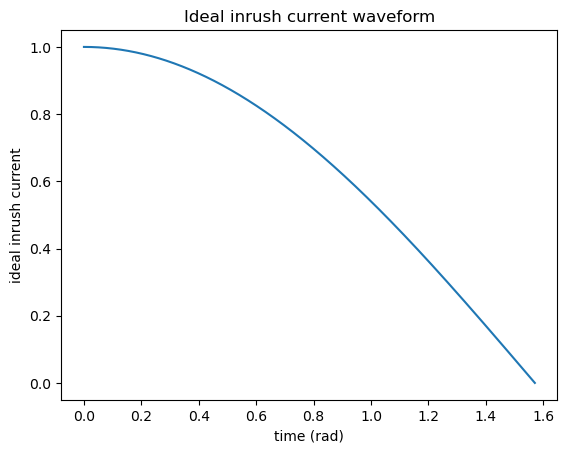

In [147]:
alpha = 2*np.pi/4
def ideal_inrush_current(x):
    return np.cos(x) - np.cos(alpha)

delta_t = 0.00001
#t_grid = np.linspace(-alpha, 2*np.pi+alpha, int(1/delta_t))
t_grid = np.linspace(0, alpha, int(1/delta_t))
I = ideal_inrush_current(t_grid)
I[I < 0] = 0
plt.plot(t_grid, I)
plt.xlabel("time (rad)")
plt.ylabel("ideal inrush current")
plt.title("Ideal inrush current waveform")

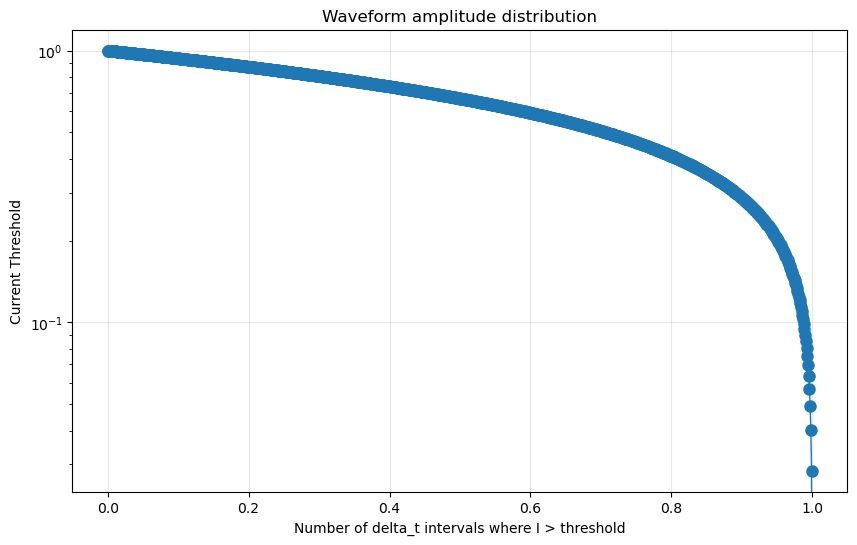

In [148]:
thresholds = np.linspace(0, I.max(), 1000)
counts = [np.sum(I > threshold)/len(I) for threshold in thresholds]

plt.figure(figsize=(10, 6))
plt.plot( thresholds, counts,marker='o', linewidth=1, markersize=8)
plt.ylabel("Current Threshold")
plt.xlabel("Number of delta_t intervals where I > threshold")
plt.title("Waveform amplitude distribution")
plt.grid(True, alpha=0.3)
#plt.xscale('log')
plt.yscale('log')
plt.show()

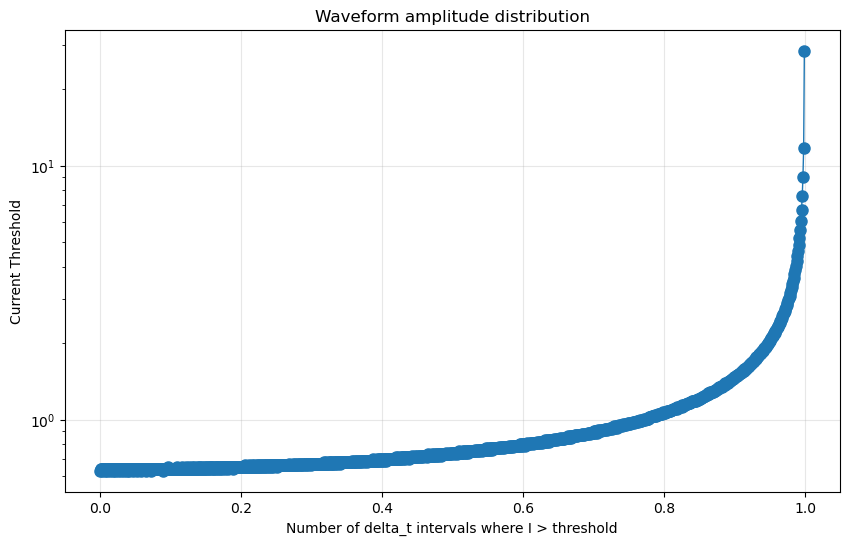

In [149]:
thresholds = np.linspace(0, I.max(), 1000)
derivative_counts = []
for i in range(len(thresholds)-1):
    derivative = (counts[i+1]-counts[i])/(thresholds[i+1]-thresholds[i])
    derivative_counts.append(-derivative)

plt.figure(figsize=(10, 6))
plt.plot( thresholds[:-1], derivative_counts,marker='o', linewidth=1, markersize=8)
plt.ylabel("Current Threshold")
plt.xlabel("Number of delta_t intervals where I > threshold")
plt.title("Waveform amplitude distribution")
plt.grid(True, alpha=0.3)
#plt.xscale('log')
plt.yscale('log')
plt.show()